# 3 - HCP effective-connectivity extraction from fitted ANN models

This notebook computes time-resolved effective connectivity matrices from the trained subject-wise ANN models generated in `HCP_2_Fit_data.ipynb`.

The notebook assumes that:

1. `HCP_1_Process_data.ipynb` has already been run and the processed arrays are available.
2. `HCP_2_Fit_data.ipynb` has already been run and trained models are available.

For each selected subject, the notebook can:

1. Load preprocessed ANN inputs and targets
2. Load the fitted model safely
3. Compute **EC(t)** using `NPI.model_ECt`
4. Optionally compute **BEC(t)** using `NPI.model_BECt`
5. Save the resulting arrays to disk
6. Provide a compact single-subject sanity-check section with visualizations

Expected repository structure:

```text
BrainStim_ANN_fMRI_HCP/
├── src/
├── notebooks/
└── Results/
    ├── processed/
    ├── ANN_model/
    ├── ECts/
    └── BECts/   (created automatically if requested)
```


In [1]:
from pathlib import Path
import sys
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.serialization
from scipy.stats import pearsonr

# -----------------------------------------------------------------------------
# Path and environment configuration
# -----------------------------------------------------------------------------
repo_dir = Path.cwd().resolve().parent
results_dir = repo_dir / "Results"
preproc_dir = results_dir / "processed"
models_dir = results_dir / "ANN_model"
ects_dir = results_dir / "ECts"
bects_dir = results_dir / "BECts"

ects_dir.mkdir(parents=True, exist_ok=True)
bects_dir.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(repo_dir))

from src import NPI

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Repository directory :", repo_dir)
print("Results directory    :", results_dir)
print("Processed data dir   :", preproc_dir)
print("Models directory     :", models_dir)
print("EC_t directory       :", ects_dir)
print("BEC_t directory      :", bects_dir)
print("PyTorch version      :", torch.__version__)
print("CUDA available       :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Running on           :", torch.cuda.get_device_name(0))
else:
    print("Running on           : CPU")


Repository directory : C:\Users\tomas\Documents\PhD\Projects\BrainStim
Results directory    : C:\Users\tomas\Documents\PhD\Projects\BrainStim\Results
Processed data dir   : C:\Users\tomas\Documents\PhD\Projects\BrainStim\Results\processed
Models directory     : C:\Users\tomas\Documents\PhD\Projects\BrainStim\Results\ANN_model
EC_t directory       : C:\Users\tomas\Documents\PhD\Projects\BrainStim\Results\ECts
BEC_t directory      : C:\Users\tomas\Documents\PhD\Projects\BrainStim\Results\BECts
PyTorch version      : 2.5.1
CUDA available       : False
Running on           : CPU


## Shared configuration

This section defines the common paths, model parameters, and subject list used by both analyses below.

The notebook is split into two clearly separated pipelines:

1. **Effective connectivity (EC(t))**
2. **Bifocal effective connectivity (BEC(t))**


In [2]:
# =============================================================================
# Shared parameters
# =============================================================================
method = "MLP"               # options depend on the models saved in Results/ANN_model
ROI_num = 450                # number of parcels / brain regions
using_steps = 3              # ANN sliding-window length
pert_strength = 0.1          # perturbation amplitude passed to NPI.model_ECt / model_BECt
max_timepoints = 500         # use None to process all available windows
compute_ECt = True
compute_BECt = True
bec_metric = "l2"
skip_existing = True

print("Shared extraction configuration:")
print("  Method               :", method)
print("  Number of regions    :", ROI_num)
print("  Window length        :", using_steps)
print("  Perturbation strength:", pert_strength)
print("  Max time points      :", max_timepoints)
print("  Compute EC(t)        :", compute_ECt)
print("  Compute BEC(t)       :", compute_BECt)
print("  BEC metric           :", bec_metric)
print("  Skip existing files  :", skip_existing)


Shared extraction configuration:
  Method               : MLP
  Number of regions    : 450
  Window length        : 3
  Perturbation strength: 0.1
  Max time points      : 500
  Compute EC(t)        : True
  Compute BEC(t)       : True
  BEC metric           : l2
  Skip existing files  : True


In [3]:
# =============================================================================
# Locate subjects with complete inputs
# =============================================================================
input_files  = sorted(preproc_dir.glob("*_inputs.npy"))
target_files = sorted(preproc_dir.glob("*_targets.npy"))
model_files  = sorted(models_dir.glob(f"*_{method}.pt"))

subject_ids_inputs = {p.name.split("_inputs.npy")[0] for p in input_files}
subject_ids_targets = {p.name.split("_targets.npy")[0] for p in target_files}
subject_ids_models = {p.name.split(f"_{method}.pt")[0] for p in model_files}

subjects = sorted(subject_ids_inputs & subject_ids_targets & subject_ids_models)

print(f"Found {len(subjects)} subjects with inputs, targets, and {method} models.")
if len(subjects) > 0:
    print("First subjects        :", subjects[:10])
else:
    print("No valid subjects found. Check Results/processed and Results/ANN_model.")


Found 100 subjects with inputs, targets, and MLP models.
First subjects        : ['id_100206', 'id_100307', 'id_100408', 'id_101006', 'id_101107', 'id_101309', 'id_101915', 'id_102008', 'id_102109', 'id_102311']


## Shared loading utilities

These helper functions are reused by both pipelines. They handle model loading, compatibility with recent PyTorch versions, and optional trimming of the time dimension.


In [4]:
# Allowlist model classes for recent PyTorch versions
torch.serialization.add_safe_globals(
    [NPI.ANN_MLP, NPI.ANN_CNN, NPI.ANN_RNN, NPI.ANN_VAR]
)


def load_model(model_path, inputs=None, targets=None):
    """Load either a full serialized model or a state-dict checkpoint."""
    ckpt = torch.load(model_path, map_location=device, weights_only=False)

    if hasattr(ckpt, "eval"):
        model = ckpt.to(device)
        model.eval()
        return model

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        method_ckpt = ckpt.get("method", method)
        roi_num_ckpt = ckpt.get("ROI_num", targets.shape[-1] if targets is not None else ROI_num)
        if inputs is not None and inputs.ndim == 2:
            using_steps_ckpt = ckpt.get("using_steps", inputs.shape[1] // roi_num_ckpt)
        else:
            using_steps_ckpt = ckpt.get("using_steps", using_steps)
        model = NPI.build_model(method_ckpt, roi_num_ckpt, using_steps_ckpt).to(device)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        return model

    raise ValueError(f"Unrecognized model file format: {model_path}")



def maybe_trim_timepoints(X, Y, max_tp=None):
    """Restrict the number of windows used for EC/BEC extraction."""
    if max_tp is None:
        return X, Y
    n_use = min(len(X), len(Y), max_tp)
    return X[:n_use], Y[:n_use]


# Part I — Effective connectivity (EC(t))

This section computes and saves **time-resolved effective connectivity matrices** for each subject in:

- `Results/ECts/<subject>_ECt.npy`

It then provides a compact summary and a single-subject sanity check.


In [11]:
# =============================================================================
# EC(t) extraction loop
# =============================================================================
ec_summary_rows = []

if not compute_ECt:
    print("compute_ECt = False -> skipping EC(t) extraction.")
else:
    for sid in subjects:
        print(f"\n================ {sid} | EC(t) ================")

        inp_path = preproc_dir / f"{sid}_inputs.npy"
        tgt_path = preproc_dir / f"{sid}_targets.npy"
        mdl_path = models_dir / f"{sid}_{method}.pt"
        ect_path = ects_dir / f"{sid}_ECt.npy"

        if not inp_path.exists() or not tgt_path.exists() or not mdl_path.exists():
            print(f"Missing inputs, targets, or model for {sid}. Skipping.")
            continue

        ec_done = ect_path.exists()
        if skip_existing and ec_done:
            print("EC(t) file already exists. Skipping.")
            continue

        X = np.load(inp_path)
        Y = np.load(tgt_path)
        X_use, Y_use = maybe_trim_timepoints(X, Y, max_timepoints)

        print("Input windows shape   :", X.shape)
        print("Target windows shape  :", Y.shape)
        print("Using windows         :", X_use.shape[0])

        model = load_model(mdl_path, X, Y)
        print("Model loaded.")

        row = {
            "subject_id": sid,
            "n_windows": X_use.shape[0],
            "ECt_saved": False,
            "status": "ok",
        }

        try:
            with torch.no_grad():
                EC_t = NPI.model_ECt(
                    model,
                    input_X=X_use,
                    target_Y=Y_use,
                    pert_strength=pert_strength,
                )
            np.save(ect_path, EC_t)
            print("EC(t) computed        :", EC_t.shape)
            print("Saved EC(t)           :", ect_path)
            row["ECt_saved"] = True
            del EC_t

        except Exception as e:
            row["status"] = f"failed: {type(e).__name__}"
            print(f"EC(t) extraction failed for {sid}: {e}")

        ec_summary_rows.append(row)

        del X, Y, X_use, Y_use, model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

ec_summary_df = pd.DataFrame(ec_summary_rows)
ec_summary_df



================ id_100206 | EC(t) ================
EC(t) file already exists. Skipping.

================ id_100307 | EC(t) ================
EC(t) file already exists. Skipping.

================ id_100408 | EC(t) ================
EC(t) file already exists. Skipping.

================ id_101006 | EC(t) ================
EC(t) file already exists. Skipping.

================ id_101107 | EC(t) ================
EC(t) file already exists. Skipping.

================ id_101309 | EC(t) ================
EC(t) file already exists. Skipping.

================ id_101915 | EC(t) ================
EC(t) file already exists. Skipping.

================ id_102008 | EC(t) ================
EC(t) file already exists. Skipping.

================ id_102109 | EC(t) ================
EC(t) file already exists. Skipping.

================ id_102311 | EC(t) ================
EC(t) file already exists. Skipping.

================ id_102513 | EC(t) ================
EC(t) file already exists. Skipping.

=========

""


In [6]:
# =============================================================================
# EC(t) output summary
# =============================================================================
if len(ec_summary_df) == 0:
    print("No EC(t) extraction summary available.")
else:
    display(ec_summary_df["status"].value_counts(dropna=False).rename("n_subjects"))
    print("\nEC(t) files found    :", len(list(ects_dir.glob("*_ECt.npy"))))


status
skipped_existing    100
Name: n_subjects, dtype: int64


EC(t) files found    : 100


### EC(t) single-subject sanity check

The following cells visualize one representative subject and inspect the magnitude and structure of the saved **EC(t)** matrices.


In [7]:
# =============================================================================
# Select one subject for visualization
# =============================================================================
if len(subjects) == 0:
    raise RuntimeError("No valid subjects were found for visualization.")

subject_to_plot = subjects[0]

inp_path = preproc_dir / f"{subject_to_plot}_inputs.npy"
tgt_path = preproc_dir / f"{subject_to_plot}_targets.npy"
ect_path = ects_dir / f"{subject_to_plot}_ECt.npy"
mdl_path = models_dir / f"{subject_to_plot}_{method}.pt"

X = np.load(inp_path)
Y = np.load(tgt_path)
X_use, Y_use = maybe_trim_timepoints(X, Y, max_timepoints)

if ect_path.exists():
    EC_t = np.load(ect_path)
else:
    model = load_model(mdl_path, X, Y)
    with torch.no_grad():
        EC_t = NPI.model_ECt(model, input_X=X_use, target_Y=Y_use, pert_strength=pert_strength)

print("Subject               :", subject_to_plot)
print("X shape               :", X.shape)
print("Y shape               :", Y.shape)
print("EC_t shape            :", EC_t.shape)


Subject               : id_100206
X shape               : (4677, 1350)
Y shape               : (4677, 450)
EC_t shape            : (500, 450, 450)


Pearson correlation between baseline energy and mean |EC(t)|: r = -0.569, p = 2.84e-44


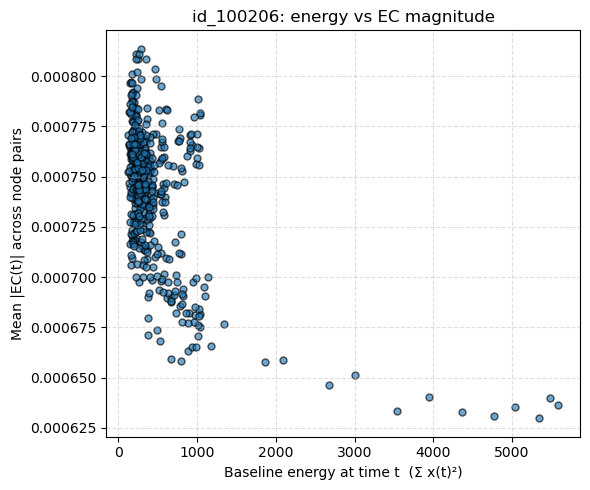

In [8]:
# =============================================================================
# Baseline energy vs mean |EC(t)|
# =============================================================================
M, N = EC_t.shape[0], EC_t.shape[1]
S = X_use.shape[1] // N

# Recover the most recent brain state from each flattened ANN window
x_t = X_use[:, -N:]
E_t = np.sum(x_t ** 2, axis=1)
EC_mean_t = np.mean(np.abs(EC_t), axis=(1, 2))

r, p = pearsonr(E_t, EC_mean_t)
print(f"Pearson correlation between baseline energy and mean |EC(t)|: r = {r:.3f}, p = {p:.3g}")

plt.figure(figsize=(6, 5))
plt.scatter(E_t, EC_mean_t, s=25, alpha=0.65, edgecolors="k")
plt.xlabel("Baseline energy at time t  (Σ x(t)²)")
plt.ylabel("Mean |EC(t)| across node pairs")
plt.title(f"{subject_to_plot}: energy vs EC magnitude")
plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.show()


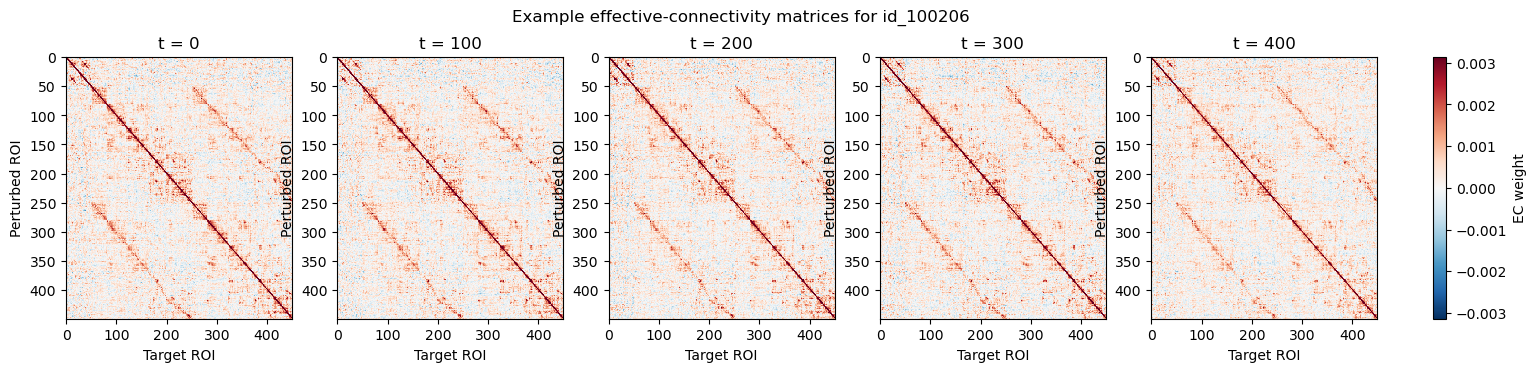

In [10]:
# =============================================================================
# Example EC(t) matrices across time
# =============================================================================
times = [0, 100, 200, 300, 400]
times = [t for t in times if t < EC_t.shape[0]]

if len(times) == 0:
    raise RuntimeError("No valid time points available for plotting.")

vabs = np.nanpercentile(np.abs(EC_t[times]), 99)
fig, axes = plt.subplots(1, len(times), figsize=(3.6 * len(times), 3.4))
if len(times) == 1:
    axes = [axes]

for ax, t in zip(axes, times):
    im = ax.imshow(EC_t[t], cmap="RdBu_r", vmin=-vabs, vmax=vabs, aspect="auto")
    ax.set_title(f"t = {t}")
    ax.set_xlabel("Target ROI")
    ax.set_ylabel("Perturbed ROI")

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04, label="EC weight")
fig.suptitle(f"Example effective-connectivity matrices for {subject_to_plot}", y=1.02)
#plt.tight_layout()
plt.show()


# Part II — Bifocal effective connectivity (BEC(t))

This section computes and saves **bifocal effective connectivity** for each subject in:

- `Results/BECts/<subject>_BECt.npy`

It is kept fully separate from EC(t) so the workflow mirrors the style of the previous notebooks more clearly.


In [ ]:
# =============================================================================
# BEC(t) extraction loop
# =============================================================================
bec_summary_rows = []

if not compute_BECt:
    print("compute_BECt = False -> skipping BEC(t) extraction.")
else:
    for sid in subjects:
        print(f"\n================ {sid} | BEC(t) ================")

        inp_path = preproc_dir / f"{sid}_inputs.npy"
        tgt_path = preproc_dir / f"{sid}_targets.npy"
        mdl_path = models_dir / f"{sid}_{method}.pt"
        bect_path = bects_dir / f"{sid}_BECt.npy"

        if not inp_path.exists() or not tgt_path.exists() or not mdl_path.exists():
            print(f"Missing inputs, targets, or model for {sid}. Skipping.")
            bec_summary_rows.append({
                "subject_id": sid,
                "n_windows": np.nan,
                "BECt_saved": False,
                "status": "missing_inputs_or_model",
            })
            continue

        bec_done = bect_path.exists()
        if skip_existing and bec_done:
            print("BEC(t) file already exists. Skipping.")
            bec_summary_rows.append({
                "subject_id": sid,
                "n_windows": np.nan,
                "BECt_saved": True,
                "status": "skipped_existing",
            })
            continue

        X = np.load(inp_path)
        Y = np.load(tgt_path)
        X_use, Y_use = maybe_trim_timepoints(X, Y, max_timepoints)

        print("Input windows shape   :", X.shape)
        print("Target windows shape  :", Y.shape)
        print("Using windows         :", X_use.shape[0])

        model = load_model(mdl_path, X, Y)
        print("Model loaded.")

        row = {
            "subject_id": sid,
            "n_windows": X_use.shape[0],
            "BECt_saved": False,
            "status": "ok",
        }

        try:
            with torch.no_grad():
                BEC_t = NPI.model_BECt(
                    model,
                    input_X=X_use,
                    target_Y=Y_use,
                    pert_strength=pert_strength,
                    metric=bec_metric,
                )
            np.save(bect_path, BEC_t)
            print("BEC(t) computed       :", BEC_t.shape)
            print("Saved BEC(t)          :", bect_path)
            row["BECt_saved"] = True
            del BEC_t

        except Exception as e:
            row["status"] = f"failed: {type(e).__name__}"
            print(f"BEC(t) extraction failed for {sid}: {e}")

        bec_summary_rows.append(row)

        del X, Y, X_use, Y_use, model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

bec_summary_df = pd.DataFrame(bec_summary_rows)
bec_summary_df


In [ ]:
# =============================================================================
# BEC(t) output summary
# =============================================================================
if len(bec_summary_df) == 0:
    print("No BEC(t) extraction summary available.")
else:
    display(bec_summary_df["status"].value_counts(dropna=False).rename("n_subjects"))
    print("\nBEC(t) files found   :", len(list(bects_dir.glob("*_BECt.npy"))))


### BEC(t) single-subject sanity check

This final cell inspects one saved **BEC(t)** output so the bifocal analysis has its own clearly separated endpoint.


In [ ]:
# =============================================================================
# Example BEC(t) inspection
# =============================================================================
bect_files = sorted(bects_dir.glob("*_BECt.npy"))
print(f"Found {len(bect_files)} saved BEC(t) files.")

if len(bect_files) > 0:
    example_bect_path = bect_files[0]
    BEC_t = np.load(example_bect_path)

    print("Example file          :", example_bect_path.name)
    print("Example BEC_t shape   :", BEC_t.shape)

    BEC_abs_mean_t = np.mean(np.abs(BEC_t.reshape(BEC_t.shape[0], -1)), axis=1)

    plt.figure(figsize=(7, 4))
    plt.plot(BEC_abs_mean_t, lw=1.8)
    plt.xlabel("Time window")
    plt.ylabel("Mean |BEC(t)|")
    plt.title(f"{example_bect_path.stem.replace('_BECt', '')}: bifocal connectivity magnitude over time")
    plt.grid(True, ls="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print("No BEC(t) files available yet.")
